# One-cavity 3LS: storage $\to$ retrieval, and the signal fidelity

Chains the two halves of a $\Lambda$-type quantum memory in the **one-cavity** model of
`three_level_one_cavity.ipynb`, reusing the building blocks in `funcs_3LS.py`:

1. **Storage** — a weak coherent signal $\alpha_{\rm in}(t)$ drives the $|g\rangle\!-\!|e\rangle$
   cavity while the optimal control $\beta_s(t)$ (Gorshkov Eq. 26, from `get_beta`) writes it
   onto the spin wave $S = \langle\hat\sigma_{gs}\rangle$.
2. **Retrieval** — the signal is switched off and a second control $\beta_r(t)$ reads the spin
   wave back out into the cavity, which leaks it to the bath.

The two stages are chained by handing the **density matrix at the end of stage 1** to stage 2 as
its initial condition, so nothing about the atom+cavity state is thrown away in between.

Finally we reconstruct the outgoing signal $\alpha_{\rm out}(t)$ from the cavity amplitude,
project it onto a single temporal mode, and evaluate

$$F = \mathrm{Tr}\big(\rho_{\rm in}\,\rho_{\rm out}\big)$$

for the signal field.

> **What is *not* reused from `funcs_3LS`.** `three_level_simulation()` returns expectation values
> only, not `result.states`, so it cannot be chained. This notebook therefore calls `mesolve`
> itself through a small `run_stage()` helper built from the module's operators, `get_beta`,
> `couplings`, `gaussian` and `get_input_values`. The cross-check cell below verifies that
> `run_stage()` reproduces `three_level_simulation(mode='cavity')` to 9 digits on the storage
> stage.

In [177]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from qutip import *

plt.rcParams['font.size'] = 16
from funcs_3LS import (
    ground, storage, excited,
    sigma_ee, sigma_ss, sigma_gg, sigma_ge, sigma_eg, sigma_se, sigma_es, sigma_gs,
    get_beta, gaussian, couplings, get_input_values, get_pulse_duration,
    three_level_simulation, plot_probs,
)

## 1. Model

$$\hat H = \big(\kappa_{ge}\,\alpha_{\rm in}(t)\,\hat a^{\dagger}_{ge} + {\rm h.c.}\big)
  + \big(g_{se}\,\beta(t)\,\hat\sigma_{se} + {\rm h.c.}\big)
  + g_{ge}\big(\hat a_{ge}\hat\sigma_{ge} + {\rm h.c.}\big)
  + \Delta\,\hat\sigma_{ee}$$

$$\mathbf{L} = \big[\,\kappa_{ge}\hat a_{ge},\;\; -g_{ge,\rm nc}^{*}\,\hat\sigma_{eg},\;\;
  -\sqrt{2\gamma_{se}}\,\hat\sigma_{es}\,\big],
\qquad g_{ge,\rm nc} = \sqrt{2\gamma_{ge}},\quad
g_{ge} = \sqrt{\tfrac{\kappa_{ge}^2}{2}\,C\,\gamma},\quad
\gamma = \gamma_{ge} + \gamma_{se}$$

$\gamma$ is the **total** coherence decay rate of $|e\rangle$ (Gorshkov App. A,
$\gamma = \tfrac12(\gamma_{eg} + \gamma_{es})$ in population rates; our $\gamma_{ge}, \gamma_{se}$
are the coherence half-rates, so each channel's population decay is $2\gamma_k$). Both $\beta(t)$
and $g_{ge}$ are built from it, so $C$ is the true cooperativity whatever the branching. The
$\hat\sigma_{es}$ term is only included when `with_es_decay = True`; the split
$\gamma_{ge} = \gamma_{se} = \gamma/2$ keeps $\gamma$, $C$ and $\beta$ fixed and moves only the
branching ratio.

Storage and retrieval differ only in the boundary conditions and in which fields are on:

| stage | $\alpha_{\rm in}$ | control | initial state |
|---|---|---|---|
| 1, storage | Gaussian | $\beta_s(t)$, Eq. (26) | $\rho_0 = |0\rangle\langle0|_{\rm cav}\otimes|g\rangle\langle g|$ |
| 2, retrieval | $0$ | $\beta_r(t)$ | $\rho(T_s)$ from stage 1 |

The amplitude $\alpha_{\rm in}$ is kept small ($n_{\rm in} = 10^{-4}$) so that the single atom is
not saturated and the dynamics is linear in the field — see the efficiency discussion in
`three_level_one_cavity.ipynb`. That linearity is also what makes the field state at the output a
*coherent* state, which section 7 relies on (and checks).

In [178]:
# ---------------- system parameters (as in three_level_one_cavity.ipynb) ----------------
C        = 100.0     # cooperativity
# |e> decay. gamma = gamma_ge + gamma_se is the TOTAL coherence decay rate (Gorshkov's gamma);
# beta(t) and g_ge are built from it. Toggling e -> s decay at fixed gamma keeps C and beta fixed
# and only moves the branching (population decay into each channel is 2*gamma_k).
with_es_decay = False
gamma_se = 0.5 if with_es_decay else 0.0    # e -> s
gamma_ge = 0.5 if with_es_decay else 1.0    # e -> g
gamma    = gamma_ge + gamma_se              # everything is in units of gamma
Delta    = 700.0     # one-photon detuning
kappa_ge = 50.0      # cavity-bath coupling, sqrt(Hz)  (kappa_Gorshkov = kappa_ge^2/2)

if with_es_decay:
    g_se = np.sqrt(2*gamma_se)
else:
    g_se = 1
    
N_cav    = 3         # Fock truncation (converged: 3, 4, 6, 8 agree to 7 digits)

g_ge, g_ge_nocav = couplings(C, gamma, mode='cavity', kappa=kappa_ge, gamma_se=gamma_se)
print(f'g_ge = {g_ge:.4f}   g_ge_nocav = {g_ge_nocav:.4f}')

# ---------------- stage windows ----------------
T_s = 10.0    # storage stage runs on [0, T_s];  retrieval starts here
T_r = 10.0    # retrieval stage runs on [T_s, T_s + T_r]
N   = 8000    # time steps per stage
assert T_r <= T_s, 'the time-reversed read control needs T_r <= T_s (see section 3)'

t_store = np.linspace(0.0, T_s, N)
t_read  = np.linspace(T_s, T_s + T_r, N)

# tolerances: QuTiP defaults are not enough here (see funcs_3LS.three_level_simulation)
OPTS = {'atol': 1e-12, 'rtol': 1e-10, 'store_states': True}

g_ge = 353.5534   g_ge_nocav = 1.4142


## 2. Input signal

Input photon number: 9.99999999999231e-05
Pulse: t_start = 0.9826, t_end = 4.0168, duration = 3.0341


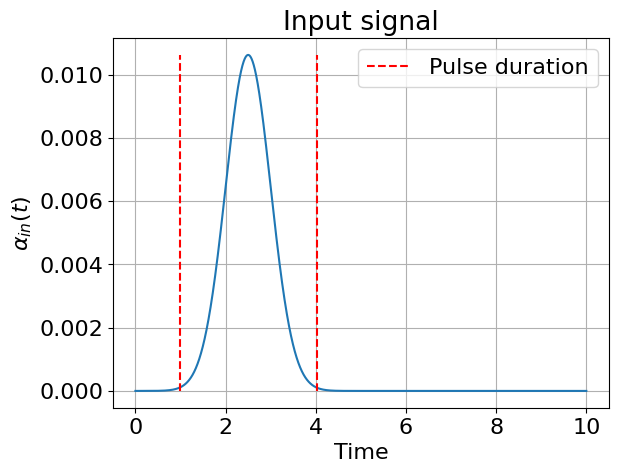

In [179]:
amp, mu, sigma = 0.01, 2.5, 0.5     # n_in = amp^2; weak field keeps the atom unsaturated

def alpha_in(t):
    return amp*gaussian(mu, sigma, t)

# funcs_3LS helper: returns the input photon number and the ABSOLUTE pulse-end time t_end,
# which is the upper limit T in h(t,T) = int_t^T |Omega|^2.
n_in, t_end = get_input_values(alpha_in, T_s, N)
plt.title('Input signal'); plt.show()

## 3. The two control fields

**Storage.** `funcs_3LS.get_beta` returns Gorshkov's optimal storage control, Eq. (26):

$$\Omega_s(t) = g_{se}\beta_s(t) = \sqrt{B}\,\frac{\mathcal{E}_{\rm in}(t)}{\sqrt{F(t)}}\,
  e^{\,i(\theta_s + \Delta h(t,T)/c)},\qquad
  F(t) = \int_0^t|\mathcal{E}_{\rm in}|^2 dt',\quad
  \theta_s = \arg\!\big[-(\gamma(1+C) - i\Delta)\big]$$

with $c = \gamma^2(1+C)^2 + \Delta^2$, $B = c/[2\gamma(1+C)]$ and $h(t,T) = -B\ln\hat F(t)$.

**Retrieval.** Gorshkov's Eq. (21) gives the control that reads the spin wave out *into a
prescribed output mode* $e(t)$:

$$|\Omega_r(t)|^2 = \frac{B\,|e(t)|^2}{\int_t^{\infty}|e|^2dt'},\qquad
  \Omega_r(t) = \sqrt{B}\,\frac{e(t)}{\sqrt{R(t)}}\,e^{\,i(\theta_r - \Delta h_r(0,t)/c)},\qquad
  \theta_r = \arg\!\big[-(\gamma(1+C) + i\Delta)\big]$$

We do **not** need to code this separately. Optimal storage is the time reverse of retrieval, and
substituting $e(t) = \mathcal{E}_{\rm in}^{*}(T-t)$ into Eq. (21) reproduces Eq. (26) term by term:

* $R(t) = \int_t^{T}|\mathcal{E}_{\rm in}(T-t')|^2dt' = F(T-t)$ — the magnitudes match;
* $h_r(0,t) = -B\ln R(t) = -B\ln F(T-t) = h(T-t,\,T)$, and $\theta_r = -\theta_s$ — so the phases
  match once conjugated.

Hence

$$\boxed{\;\Omega_r(t) = \Omega_s^{*}(t_{\rm mir} - t)\;}$$

and the retrieved mode is the **time reverse of the input mode**. With the mirror point
$t_{\rm mir} = T_s + T_r$, the read window $t \in [T_s,\,T_s+T_r]$ maps onto the storage grid
$[0, T_s]$ backwards, so the output pulse is a Gaussian of the *same width* as the input, centred
at $t_{\rm mir} - \mu$. (This is why $T_r \le T_s$ is asserted above: the mirror has to land
inside the storage grid.)

Note that neither control actually diverges here. Eq. (26) has $|\Omega|\sim1/\sqrt{F}$ as
$t\to0$, but for a Gaussian input $F(t)\simeq|\mathcal{E}_{\rm in}(t)|^2\sigma^2/(\mu-t)$ in the
leading tail, so $|\Omega|^2\to B(\mu-t)/\sigma^2$ stays finite and no $T/100$ cut-off is needed
(the same reason `three_level_one_cavity.ipynb` does not truncate).

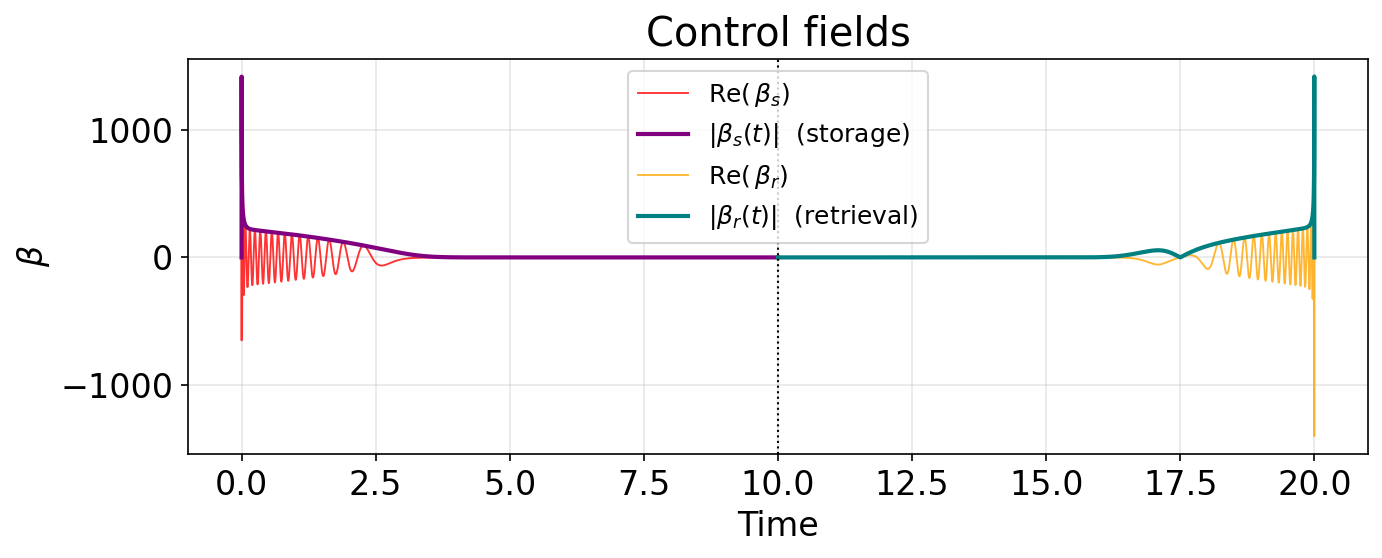

max |beta_s| = 1416.16    max |beta_r| = 1417.33
control energy   int|Omega_s|^2 = 79779.91    int|Omega_r|^2 = 76867.93


In [180]:
# ---- storage control: Gorshkov Eq. (26), straight from funcs_3LS ----
def alpha_in_orthogonal(t):
    return amp*gaussian(mu, sigma, t)*np.sin(t-mu)   # orthogonal to the original Gaussian

beta_s, h_vals, a_pref, c_pref = get_beta(alpha_in(t_store), t_store, t_end, C, gamma, Delta)

#beta_s, h_vals, a_pref, c_pref = get_beta(alpha_in_orthogonal(t_store), t_store, t_end, C, gamma, Delta)

beta_s = beta_s/g_se                   # get_beta returns Omega; g_se*beta = Omega (as in funcs_3LS)

# ---- retrieval control: the time-reversed conjugate, Omega_r(t) = Omega_s*(t_mir - t) ----
t_mir = T_s + T_r                      # mirror point
def mirror(t):
    return t_mir - t                   # t in [T_s, T_s+T_r]  ->  s in [T_s, 0] (reversed)

def _interp_c(x, xp, fp):
    """np.interp for a complex-valued fp."""
    return np.interp(x, xp, fp.real) + 1j*np.interp(x, xp, fp.imag)


beta_s_orthogonal, ignore, ignore1, ignore2 = get_beta(alpha_in_orthogonal(t_store), t_store, t_end, C, gamma, Delta)
beta_r = np.conjugate(_interp_c(mirror(t_read), t_store, beta_s_orthogonal))


fig, ax = plt.subplots(figsize=(9.5, 4),dpi=150)
ax.plot(t_store, np.real(beta_s), color='red',    lw=0.9, alpha=.8, label=r'Re($\,\beta_s$)')
ax.plot(t_store, np.abs(beta_s), color='purple', lw=2, label=r'$|\beta_s(t)|$  (storage)')
ax.plot(t_read,  np.real(beta_r), color='orange', lw=0.9, alpha=.8, label=r'Re($\,\beta_r$)')
ax.plot(t_read,  np.abs(beta_r),  color='teal',   lw=2, label=r'$|\beta_r(t)|$  (retrieval)')
ax.axvline(T_s, color='k', ls=':', lw=1)
ax.set_xlabel('Time'); ax.set_ylabel(r'$\beta$')
ax.set_title(r'Control fields')
ax.legend(fontsize=12,loc='upper center'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'max |beta_s| = {np.abs(beta_s).max():.2f}    max |beta_r| = {np.abs(beta_r).max():.2f}')
print(f'control energy   int|Omega_s|^2 = {integrate.simps(np.abs(g_se*beta_s)**2, t_store):.2f}'
      f'    int|Omega_r|^2 = {integrate.simps(np.abs(g_se*beta_r)**2, t_read):.2f}')

## 4. Operators and the stage runner

`run_stage` is `funcs_3LS.three_level_simulation(mode='cavity')` with two changes: it takes an
arbitrary initial density matrix, and it keeps `result.states` so the stages can be chained. The
Hamiltonian, collapse operators and solver tolerances are identical.

In [181]:
# cavity + atom operators (the atomic ones are lifted from funcs_3LS)
a_ge = tensor(destroy(N_cav), qeye(3))
S_ee = tensor(qeye(N_cav), sigma_ee)
S_ss = tensor(qeye(N_cav), sigma_ss)
S_gg = tensor(qeye(N_cav), sigma_gg)
S_ge = tensor(qeye(N_cav), sigma_ge)
S_eg = tensor(qeye(N_cav), sigma_eg)
S_se = tensor(qeye(N_cav), sigma_se)
S_es = tensor(qeye(N_cav), sigma_es)
S_gs = tensor(qeye(N_cav), sigma_gs)

H_static = Delta*S_ee + g_ge*(a_ge*S_ge + a_ge.dag()*S_eg)
c_ops    = [kappa_ge*a_ge, -np.conjugate(g_ge_nocav)*S_eg]
if with_es_decay:
    c_ops.append(-np.sqrt(2*gamma_se)*S_es)   # incoherent decay e -> s
#          e_ops index:  0     1     2     3          4               5
e_ops    = [S_ee, S_ss, S_gg, S_gs, a_ge.dag()*a_ge, a_ge]

def run_stage(tlist, rho0, alpha_fn, beta_vals):
    """One stage of the memory. `beta_vals` is sampled on `tlist`; `alpha_fn(t)` is the signal."""
    def beta(t):
        return _interp_c(t, tlist, beta_vals)
    H = [H_static,
         [a_ge.dag(), lambda t, args: kappa_ge*alpha_fn(t)],
         [a_ge,       lambda t, args: np.conjugate(kappa_ge*alpha_fn(t))],
         [S_se,       lambda t, args: g_se*beta(t)],
         [S_es,       lambda t, args: np.conjugate(g_se*beta(t))]]
    return mesolve(H, rho0, tlist, c_ops, e_ops=e_ops, options=OPTS)

def unpack(res):
    """-> prob_e, prob_s, prob_g, S, n_cav, <a>"""
    return (np.real(res.expect[0]), np.real(res.expect[1]), np.real(res.expect[2]),
            np.array(res.expect[3]), np.real(res.expect[4]), np.array(res.expect[5]))

## 5. Chaining the two stages

In [182]:
# ---------------- STAGE 1: STORAGE ----------------
rho0 = ket2dm(tensor(basis(N_cav, 0), ground))          # cavity empty, atom in |g>
res_s = run_stage(t_store, rho0, alpha_in, beta_s)
pe_s, ps_s, pg_s, S_s, ncav_s, a_s = unpack(res_s)

rho_mid = res_s.final_state                              # <-- the chain link
print(f'rho_ss(T_s)/n_in = {ps_s[-1]/n_in:.6f}     (population; can exceed C/(1+C) with e -> s decay)')
print(f'|S(T_s)|^2/n_in  = {abs(S_s[-1])**2/n_in:.6f}     ceiling C/(1+C) = {C/(1+C):.6f}')
print(f'coherence |S|^2/(rho_gg rho_ss) = {abs(S_s[-1])**2/(ps_s[-1]*pg_s[-1]):.6f}')
print(f'rho_mid: dims {rho_mid.dims}, trace {rho_mid.tr().real:.10f}, '
      f'purity {(rho_mid*rho_mid).tr().real:.10f}')

rho_ss(T_s)/n_in = 0.989974     (population; can exceed C/(1+C) with e -> s decay)
|S(T_s)|^2/n_in  = 0.989844     ceiling C/(1+C) = 0.990099
coherence |S|^2/(rho_gg rho_ss) = 0.999967
rho_mid: dims [[3, 3], [3, 3]], trace 1.0000000000, purity 0.9999999935


In [183]:
# ---- cross-check: does run_stage() reproduce funcs_3LS.three_level_simulation()? ----
_ref = three_level_simulation(C, gamma, Delta, T_s, t_end, N, g_se, g_ge,
                              alpha_in, alpha_in, mode='cavity', kappa=kappa_ge,
                              N_cav=N_cav, g_ge_nocav=g_ge_nocav, gamma_se=gamma_se)
print(f'\nrun_stage  eta_s = {ps_s[-1]/n_in:.10f}')
print(f'module     eta_s = {_ref.prob_s[-1]/n_in:.10f}')
print(f'max |diff| in rho_ss(t) = {np.abs(ps_s - _ref.prob_s).max():.3e}')

Area of alpha: 9.99999999999231e-05

run_stage  eta_s = 0.9899743866
module     eta_s = 0.9899743862
max |diff| in rho_ss(t) = 1.607e-13


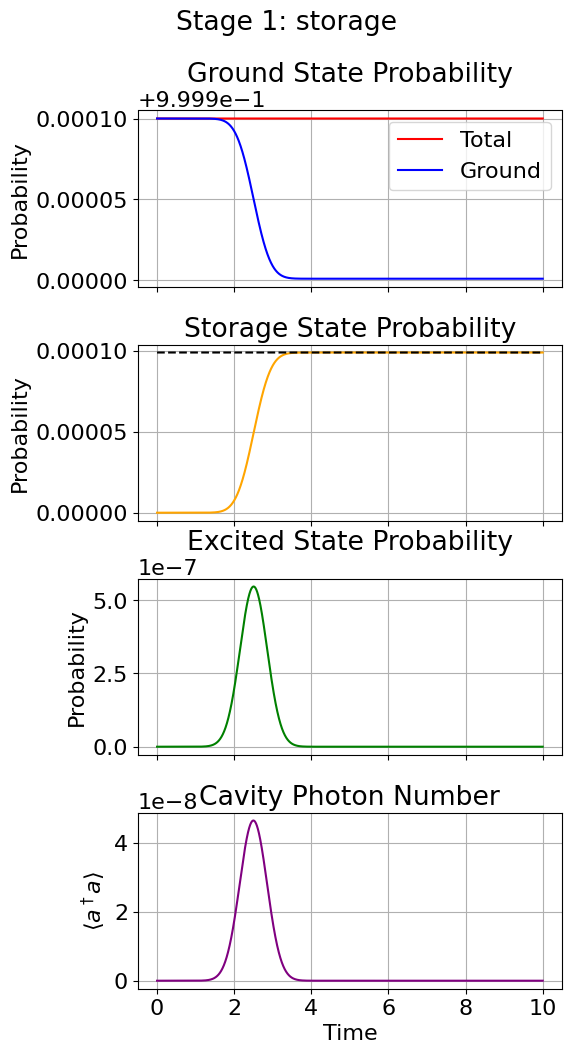

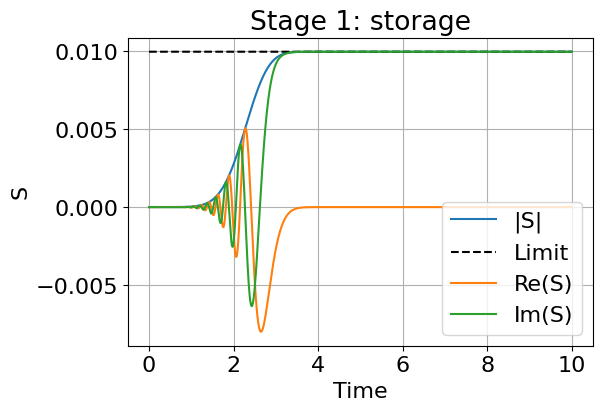

In [184]:
plot_probs(t_store, pg_s, pe_s, ps_s, S_s, n_in*C/(1+C), n_cav=ncav_s,
           title='Stage 1: storage')

In [185]:
# ---------------- STAGE 2: RETRIEVAL ----------------
# signal off, read control on, initial state = rho_mid
res_r = run_stage(t_read, rho_mid, lambda t: 0.0, beta_r)
pe_r, ps_r, pg_r, S_r, ncav_r, a_r = unpack(res_r)

print(f'spin wave left over:  rho_ss(end)/n_in            = {ps_r[-1]/n_in:.3e}')
print(f'unread fraction:      rho_ss(end)/rho_ss(T_s)      = {ps_r[-1]/ps_s[-1]:.3e}')

spin wave left over:  rho_ss(end)/n_in            = -3.091e-11
unread fraction:      rho_ss(end)/rho_ss(T_s)      = -3.122e-11


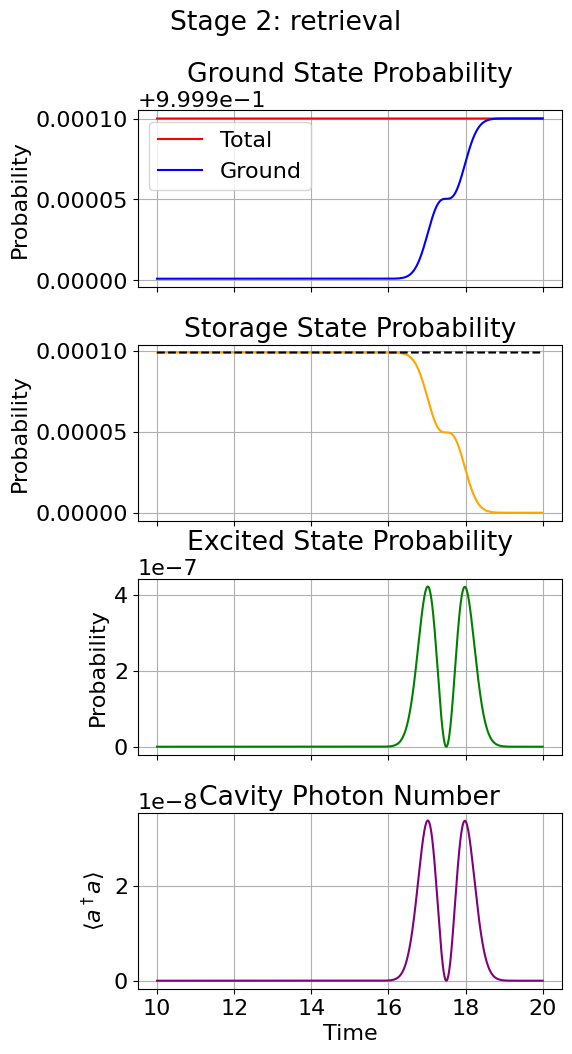

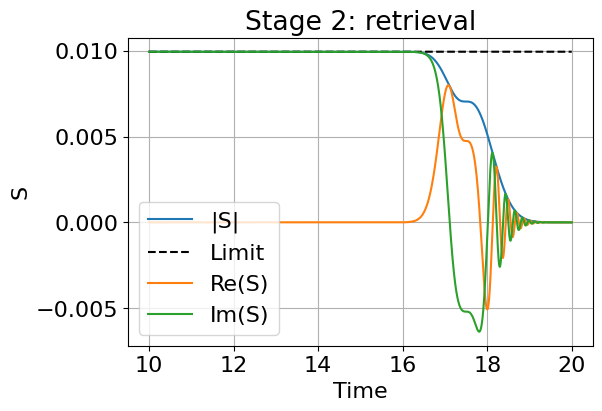

In [186]:
plot_probs(t_read, pg_r, pe_r, ps_r, S_r, n_in*C/(1+C), n_cav=ncav_r,
           title='Stage 2: retrieval')

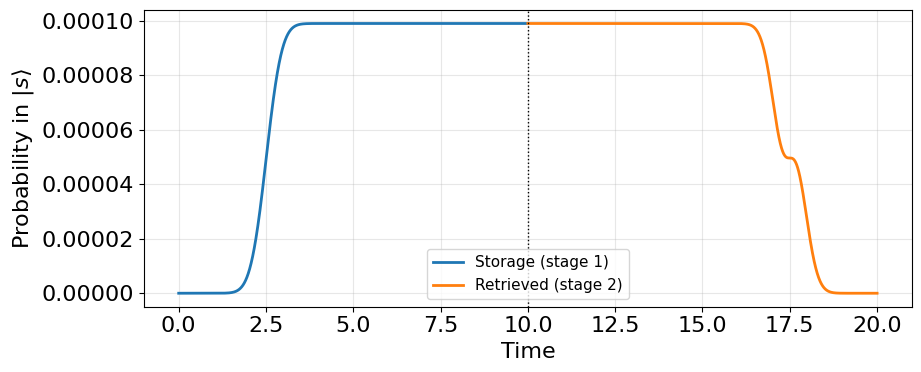

In [187]:
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(t_store, ps_s, lw=2, label=r'Storage (stage 1)')
ax.plot(t_read, ps_r, lw=2,  label=r'Retrieved (stage 2)')

ax.axvline(T_s, color='k', ls=':', lw=1)
ax.set_xlabel('Time'); ax.set_ylabel(r'Probability in $|s\rangle$')
ax.legend(fontsize=11); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

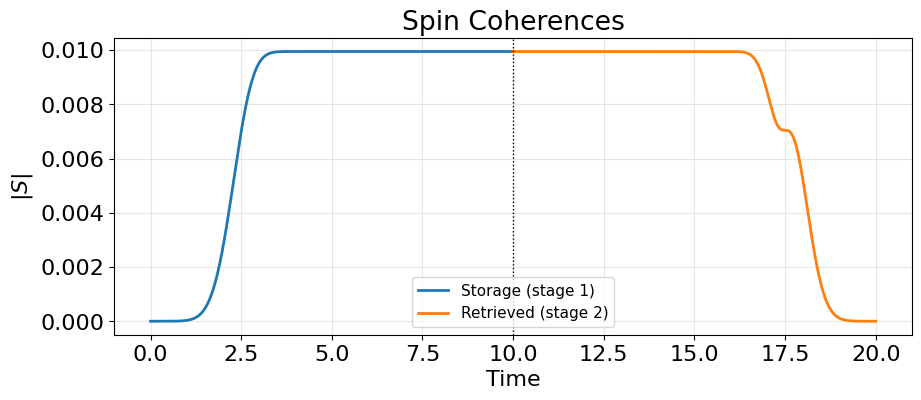

In [188]:
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(t_store, abs(S_s), lw=2, label=r'Storage (stage 1)')
ax.plot(t_read, abs(S_r), lw=2,  label=r'Retrieved (stage 2)')
ax.axvline(T_s, color='k', ls=':', lw=1)
ax.set_xlabel('Time'); ax.set_ylabel(r'$|S|$')
ax.legend(fontsize=11); ax.grid(alpha=.3)
plt.tight_layout(); 
plt.title('Spin Coherences')
plt.show()

## 6. The outgoing signal $\alpha_{\rm out}(t)$

The master equation discards the light that leaks through the mirror, so the output field has to
be reconstructed from the cavity amplitude using input-output theory (`NOTATION_vs_gorshkov.md` §4).
The matching between that theory and the notebook's Hamiltonian goes in five steps.

**Step 1 — input-output theory.** Coupling the cavity mode to the continuum outside the mirror and
eliminating the bath in the Markov limit gives the Langevin equation and the boundary condition
(Walls & Milburn; Gorshkov Eq. 2)

$$\dot{\hat a} = -i[\hat a, \hat H_{\rm sys}] - \kappa\,\hat a + \sqrt{2\kappa}\,\hat a_{\rm in}(t)$$
$$\hat a_{\rm out}(t) = \sqrt{2\kappa}\,\hat a(t) - \hat a_{\rm in}(t)$$

- $\hat a_{\rm in}$, $\hat a_{\rm out}$ have units of $\sqrt{\rm Hz}$
-  $\langle\hat a^\dagger_{\rm out}\hat a_{\rm out}\rangle$ is a photon flux.

$$\begin{align}
\dot{\hat a}_{ge}
&= -\tfrac12\kappa_{ge}^2\,\hat a_{ge}
&\;&
-\,i\kappa_{ge}\,\alpha_{\rm in}(t)
&\;&
-\,i g_{ge}\,\hat\sigma_{eg}
\\[6pt]
\dot{\hat{\mathcal E}}
&= -\kappa\,\hat{\mathcal E}
&\;&
+\,\sqrt{2\kappa}\,\mathcal E_{\rm in}
&\;&
+\,i g\sqrt N\,\hat\sigma_{eg}
\end{align}$$
- Matching, $\sqrt{2\kappa} = \kappa_{ge}$, $\mathcal{E}_{\rm in} = -i\,\alpha_{\rm in}$

Take the expectation value of the boundary condition in Step 1 and substitute:

$$\mathcal{E}_{\rm out}(t) \equiv \langle\hat a_{\rm out}(t)\rangle
  = \sqrt{2\kappa}\,\langle\hat a(t)\rangle - \mathcal{E}_{\rm in}(t)
$$

$$\mathcal{E}_{\rm out}(t) = \kappa_{ge}\,\langle\hat a(t)\rangle + i\,\alpha_{\rm in}(t).$$


$\mathcal{E}_{\rm in}$ and $\mathcal{E}_{\rm out}$ are the same bath field before and after it meets the
mirror, so the output must be expressed with the *same* phase reference as the input,
$\alpha \equiv i\,\mathcal{E}$; otherwise $\alpha_{\rm out}$ and $\alpha_{\rm in}$ would differ by a
spurious $\pi/2$ and the overlap $\gamma_{\rm out}$ in section 7 would compare amplitudes in two
different frames. Then

$$\alpha_{\rm out} = i\,\mathcal{E}_{\rm out}
  = i\kappa_{ge}\langle\hat a\rangle + i\cdot i\,\alpha_{\rm in}$$

$$\boxed{\;\alpha_{\rm out}(t) = i\,\kappa_{ge}\,\langle \hat a_{ge}(t)\rangle \;-\; \alpha_{\rm in}(t)\;}$$

The phase convention drops out of every photon number: $|\alpha_{\rm out}|^2 = |\mathcal{E}_{\rm out}|^2
= \langle\hat a^\dagger_{\rm out}\hat a_{\rm out}\rangle$ for a coherent output, so
$n_{\rm out} = \int|\alpha_{\rm out}|^2dt$ regardless. It matters only for the phase of
$\gamma_{\rm out}$.

**Sanity check.** Empty cavity ($g_{ge} = 0$), slow resonant drive: setting (B) to zero gives
$\langle\hat a\rangle = -2i\alpha_{\rm in}/\kappa_{ge}$, so
$\alpha_{\rm out} = i\kappa_{ge}(-2i\alpha_{\rm in}/\kappa_{ge}) - \alpha_{\rm in}
= 2\alpha_{\rm in} - \alpha_{\rm in} = \alpha_{\rm in}$ — full reflection with no phase shift, as a
single-sided cavity must. During retrieval $\alpha_{\rm in} = 0$, so
$\alpha_{\rm out} = i\kappa_{ge}\langle\hat a\rangle$.

target mode normalisation  int|u_tgt|^2 dt = 1.0000000000000002


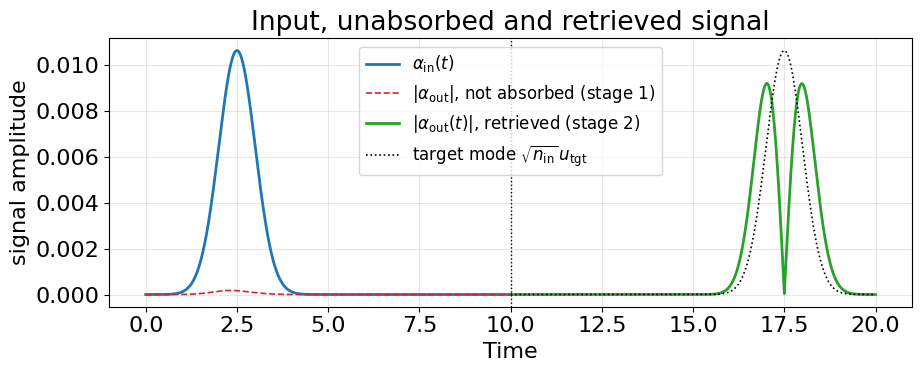

In [189]:
alpha_out_s = 1j*kappa_ge*a_s - alpha_in(t_store)   # stage 1: light that was not absorbed
alpha_out_r = 1j*kappa_ge*a_r                       # stage 2: the retrieved pulse, alpha_in = 0 

# the target output mode: the time reverse of the input mode (section 3)
u_tgt = alpha_in(mirror(t_read))/np.sqrt(n_in)
print('target mode normalisation  int|u_tgt|^2 dt =',
      integrate.simps(np.abs(u_tgt)**2, t_read))

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(t_store, alpha_in(t_store), color='C0', lw=2, label=r'$\alpha_{\rm in}(t)$')
ax.plot(t_store, np.abs(alpha_out_s), color='C3', lw=1.2, ls='--',
        label=r'$|\alpha_{\rm out}|$, not absorbed (stage 1)')
ax.plot(t_read, np.abs(alpha_out_r), color='C2', lw=2,
        label=r'$|\alpha_{\rm out}(t)|$, retrieved (stage 2)')
ax.plot(t_read, np.sqrt(n_in)*u_tgt, color='k', lw=1.2, ls=':',
        label=r'target mode $\sqrt{n_{\rm in}}\,u_{\rm tgt}$')
ax.axvline(T_s, color='k', ls=':', lw=1)
ax.set_xlabel('Time'); ax.set_ylabel('signal amplitude')
ax.set_title('Input, unabsorbed and retrieved signal')
ax.legend(fontsize=12); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

overlap               = 0.00000009 -1.91e-07j
2.1099903752694523e-07
|overlap|^2 / n_in    = 0.000000
|overlap|^2 / (n_in n_out) = 0.000005


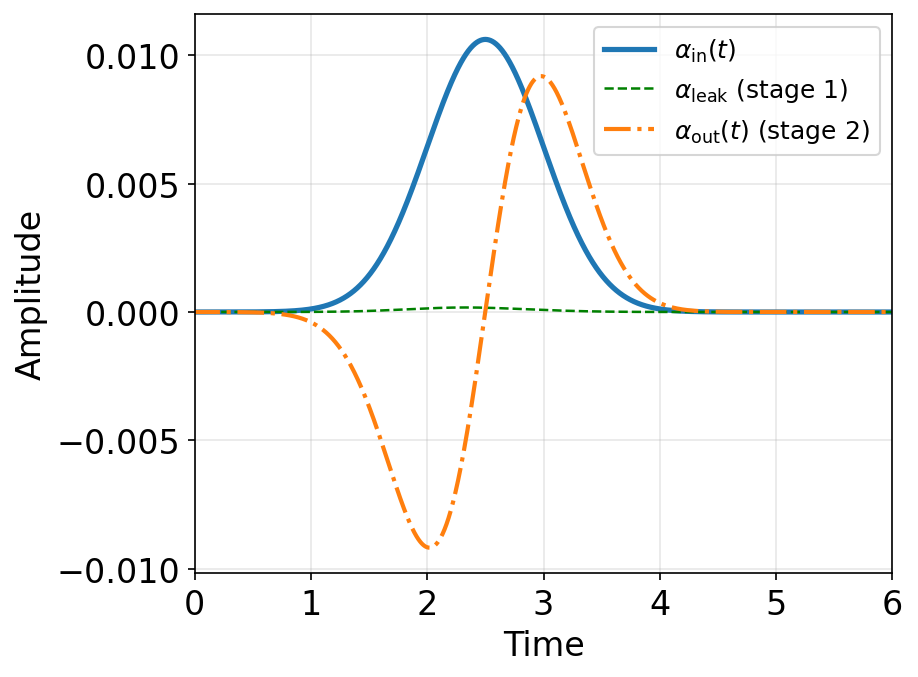

In [190]:
# alpha_out_r lives on t_read. Reversing the array puts it on mirror(t_read)[::-1],
# which is the same grid as t_store, so it lines up with alpha_in(t_store).
alpha_out_r_flip = alpha_out_r[::-1]
assert np.allclose(mirror(t_read)[::-1], t_store)

overlap = integrate.simps(np.conjugate(alpha_in(t_store))*alpha_out_r_flip, t_store)
print(f'overlap               = {overlap.real:.8f} {overlap.imag:+.2e}j')
print(abs(overlap))
print(f'|overlap|^2 / n_in    = {abs(overlap)**2/n_in:.6f}')    # retrieval efficiency in the input mode
print(f'|overlap|^2 / (n_in n_out) = {abs(overlap)**2/(n_in*n_out):.6f}')   # pure mode overlap, 1 = perfect

plt.figure(dpi=150)
plt.plot(t_store, alpha_in(t_store), lw=2.5, label=r'$\alpha_{\rm in}(t)$')
plt.plot(t_store, alpha_out_s, color='green', lw=1.2, ls='--',
        label=r'$\alpha_{\rm leak}$ (stage 1)')
plt.plot(mirror(t_read), alpha_out_r, '-.', lw=2,
        label=r'$\alpha_{\rm out}(t)$ (stage 2)')

plt.xlabel('Time'); plt.ylabel('Amplitude')
plt.xlim([0, 6])
plt.legend(fontsize=12); plt.grid(alpha=.3)

plt.tight_layout(); plt.show()

In [191]:
print(n_refl)
print(n_out)
print(n_in)
print(n_refl/(n_in*(C/(1+C))))
print(n_out/(n_in*(C/(1+C))**2))

2.8563803585797574e-08
9.800434816969909e-05
9.99999999999231e-05
0.0002884944162167774
0.9997423556798694


In [192]:
# ---------------- efficiencies and the photon budget ----------------
n_refl = integrate.simps(np.abs(alpha_out_s)**2, t_store)   # not absorbed during storage
n_out  = integrate.simps(np.abs(alpha_out_r)**2, t_read)    # retrieved
sp_s   = integrate.simps(g_ge_nocav**2*pe_s, t_store)       # spontaneous emission e -> g, stage 1
sp_r   = integrate.simps(g_ge_nocav**2*pe_r, t_read)        # spontaneous emission e -> g, stage 2

# Incoherent light leaving through the mirror. alpha_out = i*kappa_ge*<a> - alpha_in is the
# COHERENT output only; the full photon flux out of the cavity has an extra kappa_ge^2*(<a^dag a> - |<a>|^2).
# Without e -> s decay this is ~1e-4 of the output (section 7 check). With it, it is where the
# e -> s excitations go: the sigma_es jump does not remove an excitation (a^dag a + sigma_ee +
# sigma_ss is conserved by H and by that jump), it leaves the atom in |s> without g-s coherence,
# and the read control then emits that population into the cavity as light that is not
# phase-locked to the signal.
inc_s  = integrate.simps(kappa_ge**2*(ncav_s - np.abs(a_s)**2), t_store)  # incoherent, stage 1
inc_r  = integrate.simps(kappa_ge**2*(ncav_r - np.abs(a_r)**2), t_read)   # incoherent, stage 2
# e -> s scattering events (rate 2*gamma_se): not a budget term themselves, shown for reference
sp_es  = integrate.simps(2*gamma_se*pe_s, t_store) + integrate.simps(2*gamma_se*pe_r, t_read)

eta_s = ps_s[-1]/n_in
eta_r = n_out/ps_s[-1]
eta_t = n_out/n_in

print(f'eta_s   = rho_ss(T_s)/n_in   = {eta_s:.6f}    [C/(1+C)     = {C/(1+C):.6f}]')
print(f'eta_r   = n_out/rho_ss(T_s)  = {eta_r:.6f}    [C/(1+C)     = {C/(1+C):.6f}]  (coherent output; rho_ss includes incoherent |s>)')
print(f'eta_tot = n_out/n_in         = {eta_t:.6f}    [(C/(1+C))^2 = {(C/(1+C))**2:.6f}]')

tot = n_refl + n_out + sp_s + sp_r + inc_s + inc_r + ps_r[-1]
print('\nphoton budget (everything / n_in):')
print(f'  not absorbed, stage 1     {n_refl/n_in:.6f}')
print(f'  retrieved                 {n_out/n_in:.6f}')
print(f'  spontaneous, stage 1      {sp_s/n_in:.6f}     [(gamma_ge/gamma)/(1+C) = {gamma_ge/gamma/(1+C):.6f}]')
print(f'  spontaneous, stage 2      {sp_r/n_in:.6f}')
print(f'  incoherent out, stage 1   {inc_s/n_in:.6f}')
print(f'  incoherent out, stage 2   {inc_r/n_in:.6f}     (noise: not phase-locked to the signal)')
print(f'  left in |s>               {ps_r[-1]/n_in:.3e}')
print( '  ------------------------------------')
print(f'  total                     {tot/n_in:.6f}')
print(f'\n  (e -> s scattering events, both stages, for reference: {sp_es/n_in:.6f})')

# The budget closes once the incoherent output is included. The ~2e-4 that used to be missing
# here (and was put down to the near-cancellation in alpha_out_s) is the incoherent output
# from the single-atom nonlinearity, inc_s + inc_r.


eta_s   = rho_ss(T_s)/n_in   = 0.989974    [C/(1+C)     = 0.990099]
eta_r   = n_out/rho_ss(T_s)  = 0.989968    [C/(1+C)     = 0.990099]  (coherent output; rho_ss includes incoherent |s>)
eta_tot = n_out/n_in         = 0.980043    [(C/(1+C))^2 = 0.980296]

photon budget (everything / n_in):
  not absorbed, stage 1     0.000286
  retrieved                 0.980043
  spontaneous, stage 1      0.009676     [(gamma_ge/gamma)/(1+C) = 0.009901]
  spontaneous, stage 2      0.009802
  incoherent out, stage 1   0.000064
  incoherent out, stage 2   0.000129     (noise: not phase-locked to the signal)
  left in |s>               -3.091e-11
  ------------------------------------
  total                     1.000000

  (e -> s scattering events, both stages, for reference: 0.000000)


In [193]:
abs(S_s[-1])**2/n_in

0.9898438574869457

## 7. Fidelity $F = \mathrm{Tr}(\rho_{\rm in}\rho_{\rm out})$

To compare "the signal before" with "the signal after" they must be states of **one** Hilbert
space. The natural one is a single temporal mode:

* input mode $u_{\rm in}(t) = \alpha_{\rm in}(t)/\sqrt{n_{\rm in}}$ on the storage window;
* output mode $u_{\rm tgt}(t) = u_{\rm in}(t_{\rm mir}-t)$ on the retrieval window — the mode the
  memory is *designed* to emit into (section 3);

both normalised to $\int|u|^2dt = 1$. The signal's amplitude in the output mode is

$$\gamma_{\rm out} = \int u_{\rm tgt}^{*}(t)\,\alpha_{\rm out}(t)\,dt .$$

Because the field is weak the channel is linear, so the outgoing field stays **coherent** and is
fully specified by $\gamma_{\rm out}$ (checked below: in the cavity
$\langle a^\dagger a\rangle = |\langle a\rangle|^2$ to $\sim10^{-4}$ relative). Tracing away every
other temporal mode leaves a single-mode coherent state, so

$$\rho_{\rm in} = |\sqrt{n_{\rm in}}\rangle\langle\sqrt{n_{\rm in}}|,
\qquad
\rho_{\rm out} = |\gamma_{\rm out}\rangle\langle\gamma_{\rm out}| .$$

Both are built explicitly as QuTiP density matrices in a truncated Fock space, and
$F = \mathrm{Tr}(\rho_{\rm in}\rho_{\rm out})$ is evaluated as written.

In [194]:
# --- check the linearity / coherence assumption on the retrieved field ---
coh_err = np.abs(ncav_r - np.abs(a_r)**2).max()/max(ncav_r.max(), 1e-300)
print(f'coherence check:  max| <a+a> - |<a>|^2 | / max<a+a>  =  {coh_err:.2e}')

# --- amplitude of the signal in the output mode ---
gamma_out = integrate.simps(np.conjugate(u_tgt)*alpha_out_r, t_read)
alpha_amp = np.sqrt(n_in)

print(f'\ninput  amplitude  sqrt(n_in) = {alpha_amp:.8f}')
print(f'output amplitude  gamma_out  = {gamma_out.real:.8f} {gamma_out.imag:+.2e}j'
      f'   (phase {np.angle(gamma_out, deg=True):+.4f} deg)')
print(f'|gamma_out|^2 / n_in                  = {abs(gamma_out)**2/n_in:.6f}')
print(f'mode overlap |<u_tgt|a_out>|^2/n_out  = {abs(gamma_out)**2/n_out:.6f}')

coherence check:  max| <a+a> - |<a>|^2 | / max<a+a>  =  1.32e-04

input  amplitude  sqrt(n_in) = 0.01000000
output amplitude  gamma_out  = 0.00000899 -1.91e-05j   (phase -64.7899 deg)
|gamma_out|^2 / n_in                  = 0.000004
mode overlap |<u_tgt|a_out>|^2/n_out  = 0.000005


In [195]:
# ---------------- F = Tr(rho_in rho_out) ----------------
N_fock = 8                                   # truncation; the amplitudes are << 1 so this is exact

rho_in  = coherent_dm(N_fock, alpha_amp)
rho_out = coherent_dm(N_fock, gamma_out)

F_coherent = float(np.real((rho_in*rho_out).tr()))
print(f'F = Tr(rho_in rho_out)   [coherent signal, n_in = {n_in:.1e}]   =  {F_coherent:.10f}')
print(f'    closed form  exp(-|alpha - gamma|^2)                        =  '
      f'{np.exp(-abs(alpha_amp - gamma_out)**2):.10f}')
print(f'    1 - F                                                       =  {1-F_coherent:.3e}')

F = Tr(rho_in rho_out)   [coherent signal, n_in = 1.0e-04]   =  0.9999001843
    closed form  exp(-|alpha - gamma|^2)                        =  0.9999001843
    1 - F                                                       =  9.982e-05


### Why that number is $\approx 1$, and the figure of merit that is not

For two coherent states $\mathrm{Tr}(\rho_{\rm in}\rho_{\rm out}) = e^{-|\alpha-\gamma_{\rm out}|^2}$.
With $n_{\rm in} = 10^{-4}$ both states are $99.99\%$ vacuum, and vacuum is stored perfectly by any
memory — so the overlap is dominated by a component that carries no information. It is the right
number for the question as posed, but it says almost nothing about the memory. (Raising `amp`
makes it more informative but reintroduces single-atom saturation.)

The informative version asks the same question **in the one-photon sector**, which is what the
memory is for. Linearity means a single photon in $u_{\rm in}$ emerges in $u_{\rm tgt}$ with
probability $\eta = |\gamma_{\rm out}|^2/n_{\rm in}$, and as vacuum otherwise:

$$\rho_{\rm in} = |1\rangle\langle1|,\qquad
  \rho_{\rm out} = \eta\,|1\rangle\langle1| + (1-\eta)\,|0\rangle\langle0|,\qquad
  \mathrm{Tr}(\rho_{\rm in}\rho_{\rm out}) = \eta .$$

That $\eta$ factorises into the two things the memory can get wrong:

$$\eta = \underbrace{\frac{n_{\rm out}}{n_{\rm in}}}_{\text{efficiency}}\times
        \underbrace{\frac{|\gamma_{\rm out}|^2}{n_{\rm out}}}_{\text{mode overlap}}$$

In [196]:
eta_mode = abs(gamma_out)**2/n_in            # efficiency INTO the target mode

rho_in_1  = fock_dm(2, 1)
rho_out_1 = eta_mode*fock_dm(2, 1) + (1 - eta_mode)*fock_dm(2, 0)
F_single  = float(np.real((rho_in_1*rho_out_1).tr()))

print(f'F = Tr(rho_in rho_out)   [single photon]   =  {F_single:.6f}')
print(f'      = efficiency {eta_t:.6f}  x  mode overlap {abs(gamma_out)**2/n_out:.6f}')
print(f'\n   bound from the model:  (C/(1+C))^2 = {(C/(1+C))**2:.6f}')
print(f'   fraction of the bound reached       = {100*F_single/(C/(1+C))**2:.4f}%')

F = Tr(rho_in rho_out)   [single photon]   =  0.000004
      = efficiency 0.980043  x  mode overlap 0.000005

   bound from the model:  (C/(1+C))^2 = 0.980296
   fraction of the bound reached       = 0.0005%


C:\Users\bac06\AppData\Local\Temp\ipykernel_10300\1860813921.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(); plt.show()


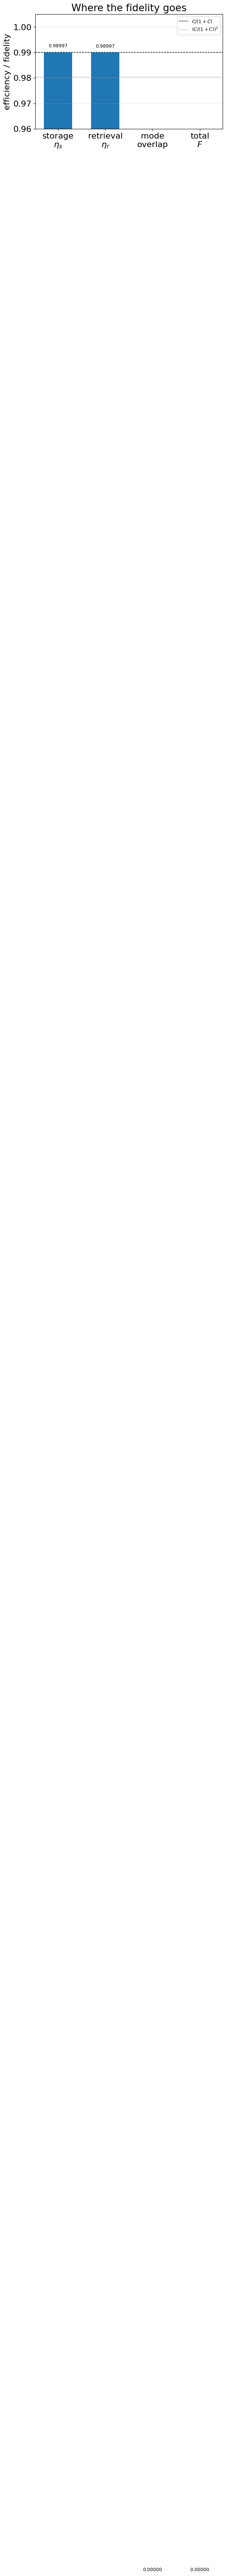

In [197]:
# --- how the fidelity is built up: efficiency vs mode mismatch ---
labels = ['storage\n$\\eta_s$', 'retrieval\n$\\eta_r$', 'mode\noverlap', 'total\n$F$']
vals   = [eta_s, eta_r, abs(gamma_out)**2/n_out, F_single]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(labels, vals, color=['C0', 'C0', 'C1', 'C2'], width=.6)
ax.axhline(C/(1+C), color='k', ls='--', lw=1, label=r'$C/(1+C)$')
ax.axhline((C/(1+C))**2, color='gray', ls=':', lw=1.2, label=r'$(C/(1+C))^2$')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.5f}', ha='center', fontsize=9)
ax.set_ylim(0.96, 1.005); ax.set_ylabel('efficiency / fidelity')
ax.set_title('Where the fidelity goes')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

## 8. Summary

| quantity | expected |
|---|---|
| $\eta_s = \rho_{ss}(T_s)/n_{\rm in}$ | $C/(1+C)$ |
| $\eta_r = n_{\rm out}/\rho_{ss}(T_s)$ | $C/(1+C)$, control-independent |
| $\eta_{\rm tot}$ | $(C/(1+C))^2$ |
| mode overlap with $u_{\rm tgt}$ | $\to1$ as $TC\gamma\to\infty$ |
| $F = \mathrm{Tr}(\rho_{\rm in}\rho_{\rm out})$, coherent | $\approx1$ (vacuum-dominated) |
| $F = \mathrm{Tr}(\rho_{\rm in}\rho_{\rm out})$, one photon | $\eta_{\rm tot}\times$ overlap |

Caveats carried over from the underlying model:

* Spin-wave decay $\gamma_s = 0$, so the hold time between write and read is free. Putting it back
  makes $\eta_r$ control-dependent and breaks the time-reversal identity used in section 3
  (`NOTATION_vs_gorshkov.md`, "Spin-wave decay").
* $N = 1$ atom, so the residual deficit from $C/(1+C)$ is single-atom saturation,
  $\approx0.65\,n_{\rm in}$. Lower `amp` to chase the linear-theory number.
* Optional e $\to$ s decay (`with_es_decay`) at fixed total $\gamma$ leaves $|S|^2$ unchanged and adds
  incoherent $|s\rangle$ population (about $(\gamma_{se}/\gamma)/(1+C)\cdot n_{\rm in}/2$), so
  $\rho_{ss}/n_{\rm in}$ can exceed $C/(1+C)$. That population is not phase-locked to the signal: the read
  control emits it through the cavity as incoherent light (budget line "incoherent out",
  $\kappa_{ge}^2\int(\langle a^\dagger a
angle - |\langle a
angle|^2)dt$), so it adds noise, not
  efficiency: $n_{
m out}$, $\gamma_{
m out}$ and $F$ are unchanged, and the coherent-output check of
  section 7 rises from $\sim10^{-4}$ to $\sim10^{-2}$.
* The output field is reconstructed from $\langle\hat a\rangle$ and assumed coherent; that is
  exact in the linear regime and checked numerically in section 7.